# ...

# Workflow Database

In [1]:
from cosim import Flow
import cosim.db as db

* List available workflows

In [2]:
db.ListFlows()

['example', 'simplest']

* Get all available workflows as dict

In [3]:
Flows = db.GetFlows(Creator=None) #<--- set Creator=None to get dict object
Flows

{'example': {'E': {'inputs': ('x',), 'outputs': ('y1', 'y2')},
  'I1': {'inputs': ('y1',), 'outputs': ('z1',)},
  'I2': {'inputs': ('y2',), 'outputs': ('z2',)},
  'X': {'inputs': ('z1', 'z2'), 'outputs': ('o',)}},
 'simplest': {'E': {'inputs': ('x',), 'outputs': ('y',)},
  'I': {'inputs': ('y',), 'outputs': ('z',)},
  'X': {'inputs': ('z',), 'outputs': ('o',)}}}

In [4]:
Flows = db.GetFlows(Creator=Flow) #<--- set Creator=Flow to get Flow object (nx.Digraph)
Flows

{'example': <cosim.flow.Flow at 0x7f59f9211fa0>,
 'simplest': <cosim.flow.Flow at 0x7f59b9498080>}

* View all available workflows

[0] Flow: example/example, Tasks: 4


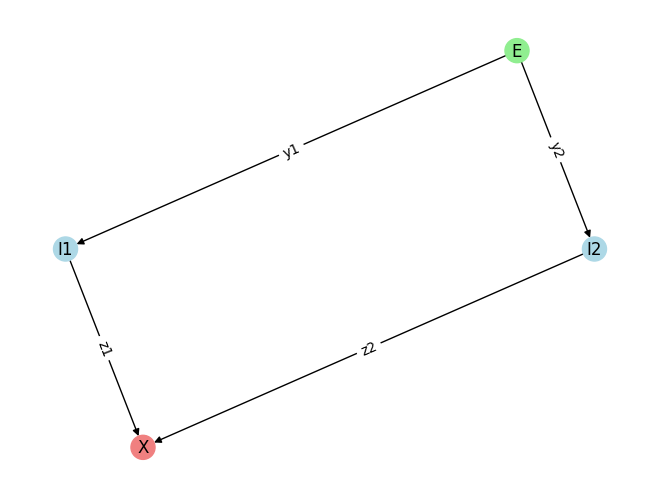

[1] Flow: simplest/simplest, Tasks: 3


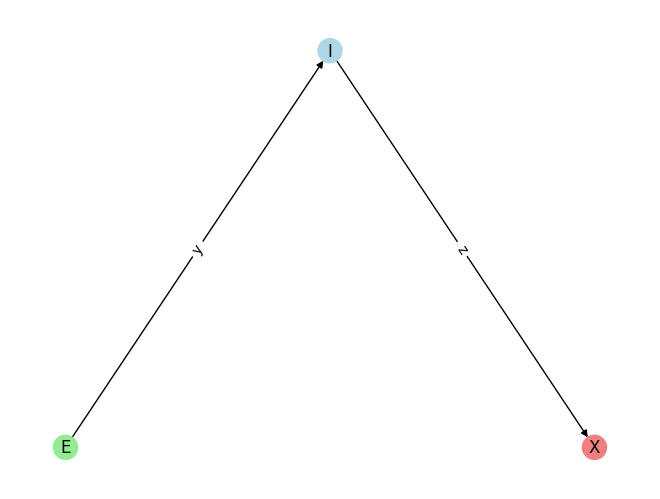

In [5]:
for i,(name, flow) in enumerate(Flows.items()):
    print(f'[{i}] Flow: {name}/{flow.NAME}, Tasks: {len(flow)}')
    flow.render()

# Working with single flows

In [6]:
from cosim import Flow
import cosim.db as db
FlowList = db.ListFlows()
FlowList

['example', 'simplest']

In [7]:
flow_name = 'example'

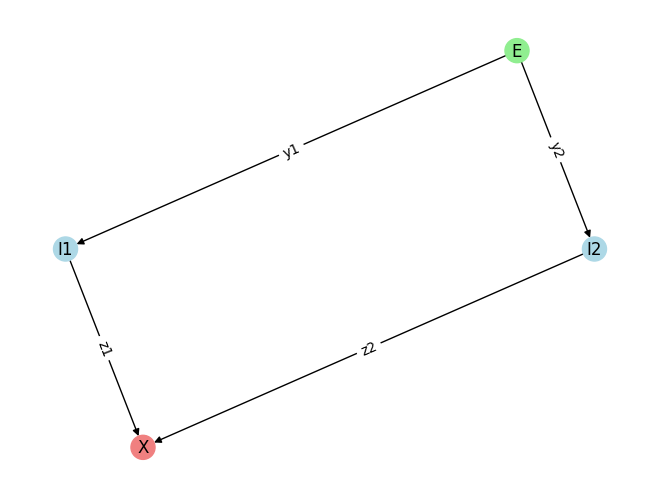

In [8]:
flow = db.GetFlow(flow_name, Creator=Flow)
flow.render()

In [9]:
flow.INFO

{'E': {'inputs': ('x',), 'outputs': ('y1', 'y2')},
 'I1': {'inputs': ('y1',), 'outputs': ('z1',)},
 'I2': {'inputs': ('y2',), 'outputs': ('z2',)},
 'X': {'inputs': ('z1', 'z2'), 'outputs': ('o',)}}

In [10]:
flow.NAME, flow.NODES, flow.ENTRY, flow.EXIT

('example', ['E', 'I1', 'I2', 'X'], 'E', 'X')

In [11]:
for n in flow.nodes: print(n, flow.nodes[n])

E {'inputs': ('x',), 'outputs': ('y1', 'y2'), 'subset': 0}
I1 {'inputs': ('y1',), 'outputs': ('z1',), 'subset': 1}
I2 {'inputs': ('y2',), 'outputs': ('z2',), 'subset': 1}
X {'inputs': ('z1', 'z2'), 'outputs': ('o',), 'subset': 2}


In [12]:
for e in flow.edges: print(e, flow.edges[e])

('E', 'I1') {'data': 'y1'}
('E', 'I2') {'data': 'y2'}
('I1', 'X') {'data': 'z1'}
('I2', 'X') {'data': 'z2'}
